# Prototype Stability-Relevant Landfast-Ice Morphology Index from SWOT KaRIn Height and Backscatter

This notebook is a weekend-scale research prototype. It uses the published Beaufort Sea SWOT-ICESat-2 dataset to build and stress-test a **candidate stability-relevant morphology index** from SWOT KaRIn 2D height/freeboard and backscatter fields.

Core question:

> Can local roughness, height-gradient, and backscatter-texture metrics from SWOT KaRIn identify coherent landfast-ice morphology features that are plausibly relevant to mechanical stability?

The output is an interpretable morphology index, not a confirmed ridge, grounding, anchoring, stability, or thickness product.

## Novelty and Scope

This prototype does not claim that SWOT-based ridge or roughness detection is itself novel. Existing work has already demonstrated SWOT's utility for sea-ice morphology, freeboard, lead/floe discrimination, velocity, and ridging in Beaufort Sea landfast ice.

The potentially novel direction here is using SWOT-derived 2D morphology as a **stability-relevant index** that can later be evaluated against landfast-ice persistence or breakout behavior.

Longer-term hypothesis:

> SWOT-derived 2D morphology metrics, when combined later with SAR persistence masks, breakout dates, bathymetry, and model output, may help evaluate landfast-ice anchoring, persistence, and breakout susceptibility.

For the current notebook, the immediate contribution is narrower: develop a simple stability morphology index (SMI), compare it with ICESat-2 along-track structure, and test whether it is robust to algorithmic choices.

## Scientific Cautions

- High-index areas are **candidate stability-relevant morphology features** only.
- The index does not confirm grounded ridges, anchor points, thickness anomalies, or stable landfast-ice zones.
- No thickness retrieval is attempted.
- Landfast ice is defined by attachment and low motion, so a stronger version needs SAR persistence or velocity information.
- SWOT sea-ice artifacts remain possible, including swath-side differences, calibration effects, temporal height errors, and along/across-track structure.
- The ICESat-2 comparison in the primary case is spatially overlapping but temporally offset by 8 days, so it is partial support rather than definitive validation.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

import swot_landfast_utils as swot_utils

warnings.filterwarnings("ignore", category=RuntimeWarning)

DATA_DIR = Path("data/raw")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

## 1. Download and Inspect the Zenodo Dataset

Dataset: [SWOT and ICESat-2 Sea Ice Height and Backscatter: Beaufort Sea, selected April - June 2023](https://zenodo.org/records/15238132).

The helper skips the 48-byte placeholder NetCDF and caches the other NetCDF files in `data/raw/`.

In [2]:
file_table = swot_utils.zenodo_file_table()
display(file_table[["key", "size", "checksum"]])

nc_paths = swot_utils.download_zenodo_netcdfs(DATA_DIR)
print(f"Cached {len(nc_paths)} NetCDF files in {DATA_DIR.resolve()}")

,key,size,checksum
0,Fischer_et_al_2025_Data_Description_README.docx,7646373,md5:06276eab1b5374780f434c7565e45074
1,UMD_IC2_0174_BeaufortSea_Study_Region_01_20230...,2719899,md5:03bd27b49df9d89d1744b1bf21c56ee7
2,UMD_IC2_0174_BeaufortSea_Study_Region_02_20230...,19445832,md5:4ad9919a3dee1fb7ad197ffff18a2d81
3,UMD_IC2_0251_BeaufortSea_Study_Region_03_20230...,2170320,md5:c0c3fd48b3760e583f20324ea72429af
4,UMD_SWOT_024_BeaufortSea_Study_Region_01_20230...,180598,md5:33aa5963e738e6de8fe5527b5cf80d7e
5,UMD_SWOT_024_BeaufortSea_Study_Region_02_20230...,48,md5:dfb3616febd977c6320504153a58885f
6,UMD_SWOT_024_BeaufortSea_Study_Region_02_20230...,7217408,md5:ecc1e3d533b904911dcb89a47426ec72
7,UMD_SWOT_024_BeaufortSea_Study_Region_02_20230...,7228331,md5:aa371bfe0ee5378cc084aae65cfe4422
8,UMD_SWOT_024_BeaufortSea_Study_Region_02_20230...,7428993,md5:d85b477dedb71b45fb208f7aa38316b4
9,UMD_SWOT_024_BeaufortSea_Study_Region_02_20230...,7369682,md5:b0ff0c0e4db61497dfcd1f16c9dd3e7c


Cached 9 NetCDF files in C:\Users\as1612\Desktop\swot_landfast_morphology_probe\data\raw


In [3]:
inventory = swot_utils.netcdf_inventory(sorted(DATA_DIR.glob("*.nc")))
display(inventory)

,file,group,variable,dimensions,shape,dtype,units,long_name
0,UMD_IC2_0174_BeaufortSea_Study_Region_01_20230...,/gt1l,longitude,x,63540,float64,degrees east,
1,UMD_IC2_0174_BeaufortSea_Study_Region_01_20230...,/gt1l,latitude,x,63540,float64,degrees north,
2,UMD_IC2_0174_BeaufortSea_Study_Region_01_20230...,/gt1l,datetime,x,63540,int32,seconds since 2000-01-01,
3,UMD_IC2_0174_BeaufortSea_Study_Region_01_20230...,/gt1l,distance,x,63540,float64,m,along-track distance
4,UMD_IC2_0174_BeaufortSea_Study_Region_01_20230...,/gt1l,freeboard_20m,x,63540,float64,m,20 m running mean freeboard
...,...,...,...,...,...,...,...,...
91,UMD_SWOT_026_BeaufortSea_Study_Region_03_20230...,/left,longitude,"x_along, y_across",1509 x 201,float64,degrees east,
92,UMD_SWOT_026_BeaufortSea_Study_Region_03_20230...,/left,latitude,"x_along, y_across",1509 x 201,float64,degrees north,
93,UMD_SWOT_026_BeaufortSea_Study_Region_03_20230...,/left,datetime,"x_along, y_across",1509 x 201,int32,seconds since 2000-01-01,
94,UMD_SWOT_026_BeaufortSea_Study_Region_03_20230...,/left,sea_ice_height,"x_along, y_across",1509 x 201,float64,m,sea ice height with respect to DTU21MSS


## 2. Select a Beaufort Sea Prototype Case

Primary morphology-index scene:

- SWOT file: `UMD_SWOT_024_BeaufortSea_Study_Region_02_20230409.nc`
- SWOT swath: `left`
- Main SWOT fields: `sea_ice_height` and `backscatter`

ICESat-2 comparison:

- ICESat-2 file: `UMD_IC2_0174_BeaufortSea_Study_Region_02_20230401.nc`
- Beam: `gt2l`
- Fields: `sea_ice_height_20m` and `sea_ice_height_500m`

This pairing gives a clear 2D SWOT scene and an ICESat-2 track crossing the swath. The temporal offset matters: ICESat-2 is from 2023-04-01 and SWOT is from 2023-04-09.

In [4]:
SWOT_FILE = DATA_DIR / "UMD_SWOT_024_BeaufortSea_Study_Region_02_20230409.nc"
SWOT_SWATH = "left"
ICESAT2_FILE = DATA_DIR / "UMD_IC2_0174_BeaufortSea_Study_Region_02_20230401.nc"
ICESAT2_BEAM = "gt2l"

swot = swot_utils.open_swot(SWOT_FILE, swath=SWOT_SWATH)
ic2 = swot_utils.open_icesat2(ICESAT2_FILE, beam=ICESAT2_BEAM)

print(swot)
print(f"ICESat-2 points in beam {ICESAT2_BEAM}: {len(ic2):,}")
print(ic2[["lon", "lat", "distance_m", "height_20m", "height_500m", "height_source"]].head())

<xarray.Dataset> Size: 9MB
Dimensions:   (x_along: 1246, y_across: 201)
Coordinates:
    lon       (x_along, y_across) float64 2MB -141.8 -141.8 ... -133.1 -133.1
    lat       (x_along, y_across) float64 2MB ...
Dimensions without coordinates: x_along, y_across
Data variables:
    datetime  (x_along, y_across) int32 1MB ...
    height    (x_along, y_across) float64 2MB ...
    sigma0    (x_along, y_across) float64 2MB ...
Attributes:
    long_name:      left swath
    source_file:    UMD_SWOT_024_BeaufortSea_Study_Region_02_20230409.nc
    source_path:    data\raw\UMD_SWOT_024_BeaufortSea_Study_Region_02_2023040...
    swath:          left
    height_source:  sea_ice_height
ICESat-2 points in beam gt2l: 472,593
          lon        lat  distance_m  height_20m  height_500m   height_source
0 -137.441476  72.708717  252.748258    0.191054          NaN  sea_ice_height
1 -137.441479  72.708723  253.457193    0.189986          NaN  sea_ice_height
2 -137.441482  72.708729  254.166277    0.19

## 3. Provisional Analysis Mask and Pixel Spacing

The Region 02 SWOT files do not include `ice_type_flag`, so this prototype uses a conservative provisional ice-like analysis mask:

- finite height/freeboard
- finite sigma0/backscatter
- height/freeboard between -1 and 3 m, excluding obvious gross outliers

This is not a landfast-ice mask. It only defines the grid cells where the morphology index is evaluated.

In [5]:
height = swot["height"].values.astype(float)
sigma0 = swot["sigma0"].values.astype(float)
valid_mask, mask_info = swot_utils.provisional_ice_mask(height, sigma0=sigma0)
spacing = swot_utils.infer_pixel_spacing_m(swot["lon"].values, swot["lat"].values)

print(mask_info["criteria"])
print(f"Valid pixels: {valid_mask.sum():,} / {valid_mask.size:,}")
print("Inferred spacing (m):", spacing)
print("Height source:", swot.attrs.get("height_source"))

finite height/freeboard; -1.0 <= height/freeboard <= 3.0 m; finite sigma0/backscatter
Valid pixels: 159,046 / 250,446
Inferred spacing (m): {'along_m': 239.46713586710388, 'across_m': 249.8980091218874, 'median_m': 244.68257249449564}
Height source: sea_ice_height


## 4. Build the Stability Morphology Index

Metrics are computed for 500 m, 1 km, and 2 km windows. The 1 km window is used for the main map and cross-section.

The combined stability morphology index (SMI) is:

```text
SMI = z(local height/freeboard standard deviation)
    + z(height/freeboard gradient magnitude)
    + z(local sigma0/backscatter standard deviation)
```

Two component variants are also retained for uncertainty testing:

- `height_only_smi = z(local height/freeboard std) + z(height/freeboard gradient magnitude)`
- `backscatter_only_smi = z(local sigma0/backscatter std)`

Pixels above a threshold are called **high-index roughness features** or **candidate stability-relevant morphology features**.

In [6]:
WINDOWS_M = [500, 1000, 2000]
metrics_by_window = {
    window_m: swot_utils.compute_morphology(swot, window_m=window_m, valid_mask=valid_mask)
    for window_m in WINDOWS_M
}
metrics = metrics_by_window[1000]
smi = metrics["stability_morphology_index"].values
valid = metrics["valid_mask"].values.astype(bool)

high_index_mask, high_index_threshold, high_index_label = swot_utils.index_mask(
    smi, valid_mask=valid, quantile=0.90
)
feature_labels, high_index_features = swot_utils.label_index_features(high_index_mask, spacing=spacing, min_pixels=4)

print(metrics.attrs)
print(f"SMI threshold ({high_index_label}): {high_index_threshold:.3f}")
print(f"High-index pixels: {high_index_mask.sum():,}")
display(high_index_features.sort_values("area_km2", ascending=False).head(15))

{'window_m': 1000.0, 'window_pixels_along': 4, 'window_pixels_across': 4, 'spacing_along_m': 239.46713586710388, 'spacing_across_m': 249.8980091218874, 'mask_criteria': 'user-supplied valid mask', 'smi_definition': 'z(local height/freeboard std) + z(height/freeboard gradient magnitude) + z(local sigma0 std)', 'height_only_smi_definition': 'z(local height/freeboard std) + z(height/freeboard gradient magnitude)', 'backscatter_only_smi_definition': 'z(local sigma0 std)'}
SMI threshold (top 10%): 2.528
High-index pixels: 15,886


,feature_id,pixel_count,area_km2
29,30,1079,64.569907
81,82,1012,60.560469
6,7,866,51.823484
375,376,552,33.032983
209,210,501,29.981023
0,1,487,29.143230
391,392,380,22.740097
400,401,264,15.798383
431,432,226,13.524373
403,404,211,12.626738


## 5. ICESat-2 Comparison

ICESat-2 points are sampled against the SWOT SMI with nearest-neighbor matching in a local projected coordinate system. Matches farther than 750 m from a valid SWOT SMI cell are dropped.

The comparison checks whether high-index SWOT areas correspond to elevated ICESat-2 height or local along-track variability. The simple variability diagnostic is `abs(height_20m - height_500m)`.

In [7]:
sampled_smi = swot_utils.sample_grid_nearest(
    swot["lon"].values,
    swot["lat"].values,
    smi,
    ic2["lon"].values,
    ic2["lat"].values,
    max_distance_m=750,
    valid_mask=valid,
).rename(columns={"sampled_value": "swot_smi"})

sampled_height = swot_utils.sample_grid_nearest(
    swot["lon"].values,
    swot["lat"].values,
    swot["height"].values,
    ic2["lon"].values,
    ic2["lat"].values,
    max_distance_m=750,
    valid_mask=valid,
).rename(columns={"sampled_value": "swot_height"})[["swot_height"]]

points = pd.concat([ic2.reset_index(drop=True), sampled_smi, sampled_height], axis=1)
points["high_smi_sample"] = points["swot_smi"] >= high_index_threshold
points["ic2_abs_20m_minus_500m"] = (points["height_20m"] - points["height_500m"]).abs()
points_valid = points[np.isfinite(points["swot_smi"])].copy()

q95 = points_valid["swot_smi"].quantile(0.95)
top5 = points_valid[points_valid["swot_smi"] >= q95]
background = points_valid[points_valid["swot_smi"] < q95]
comparison = pd.DataFrame(
    {
        "group": ["top 5% sampled SMI", "background sampled SMI"],
        "n_points": [len(top5), len(background)],
        "mean_ic2_height_20m_m": [top5["height_20m"].mean(), background["height_20m"].mean()],
        "p95_ic2_height_20m_m": [top5["height_20m"].quantile(0.95), background["height_20m"].quantile(0.95)],
        "mean_abs_20m_minus_500m_m": [top5["ic2_abs_20m_minus_500m"].mean(), background["ic2_abs_20m_minus_500m"].mean()],
    }
)

print(f"Matched ICESat-2 points: {len(points_valid):,} / {len(points):,}")
display(comparison)

Matched ICESat-2 points: 106,422 / 472,593


,group,n_points,mean_ic2_height_20m_m,p95_ic2_height_20m_m,mean_abs_20m_minus_500m_m
0,top 5% sampled SMI,5342,0.259094,0.596607,0.087473
1,background sampled SMI,101080,0.239981,0.552007,0.066994


In [8]:
# Choose a cross-section centered on a high-SMI point with elevated ICESat-2 variability.
eligible = points_valid[
    np.isfinite(points_valid["distance_m"])
    & np.isfinite(points_valid["height_20m"])
    & np.isfinite(points_valid["height_500m"])
].copy()
eligible_top = eligible[eligible["swot_smi"] >= eligible["swot_smi"].quantile(0.95)].copy()
center_distance = float(
    eligible_top.sort_values("ic2_abs_20m_minus_500m", ascending=False).iloc[0]["distance_m"]
)
segment = eligible[
    (eligible["distance_m"] >= center_distance - 15_000)
    & (eligible["distance_m"] <= center_distance + 15_000)
].sort_values("distance_m")

print(f"Cross-section center distance: {center_distance/1000:.2f} km")
print(f"Segment points: {len(segment):,}")

Cross-section center distance: 244.72 km
Segment points: 41,855


## 6. Main Figures

WindowsPath('figures/four_panel_smi_region02_left_20230409.png')

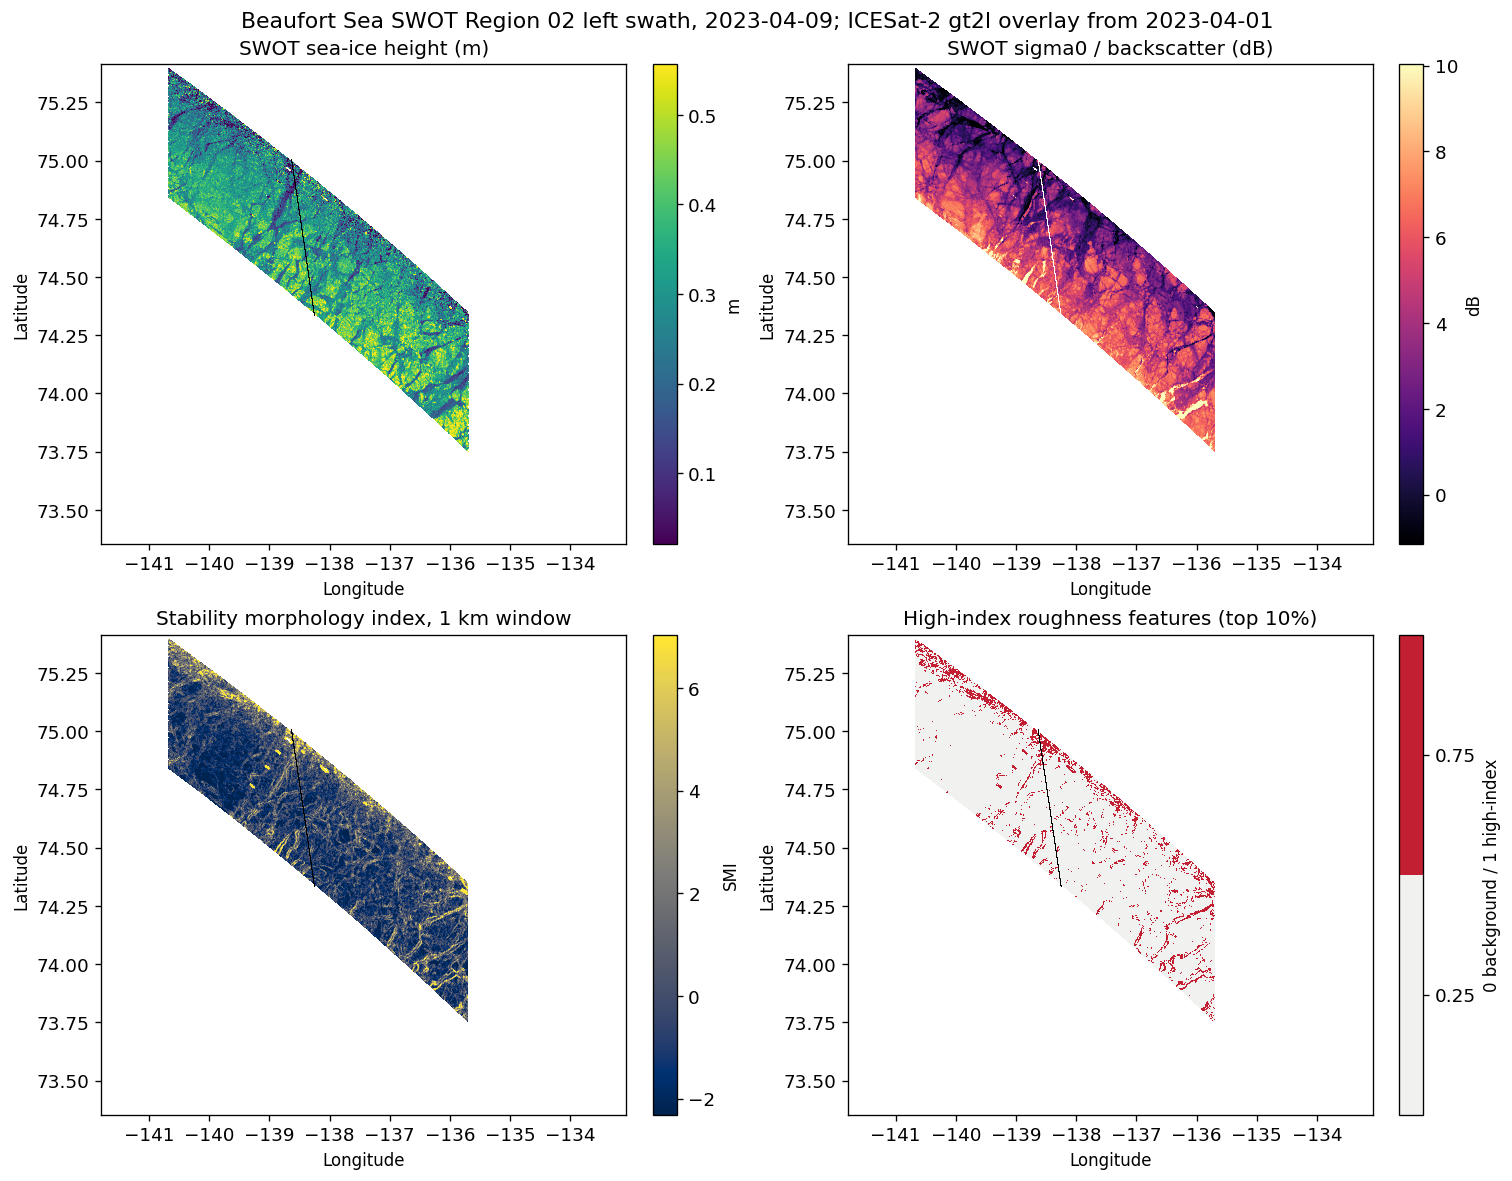

In [9]:
def add_track(ax, frame, color="black", alpha=0.28, size=0.3):
    ax.scatter(frame["lon"], frame["lat"], s=size, c=color, alpha=alpha, linewidths=0, label="ICESat-2 gt2l")

lon = swot["lon"].values
lat = swot["lat"].values
masked_height = np.where(valid, height, np.nan)
masked_sigma0 = np.where(valid, sigma0, np.nan)
masked_smi = np.where(valid, smi, np.nan)
masked_high_index = np.where(valid, high_index_mask.astype(float), np.nan)

height_limits = (np.nanpercentile(masked_height, 1), np.nanpercentile(masked_height, 99))
sigma_limits = (np.nanpercentile(masked_sigma0, 1), np.nanpercentile(masked_sigma0, 99))
smi_limits = (np.nanpercentile(masked_smi, 5), np.nanpercentile(masked_smi, 99))

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9.5), constrained_layout=True)

im = axes[0, 0].pcolormesh(lon, lat, masked_height, shading="auto", cmap="viridis", vmin=height_limits[0], vmax=height_limits[1])
add_track(axes[0, 0], points_valid)
axes[0, 0].set_title("SWOT sea-ice height (m)")
fig.colorbar(im, ax=axes[0, 0], label="m")

im = axes[0, 1].pcolormesh(lon, lat, masked_sigma0, shading="auto", cmap="magma", vmin=sigma_limits[0], vmax=sigma_limits[1])
add_track(axes[0, 1], points_valid, color="white", alpha=0.30)
axes[0, 1].set_title("SWOT sigma0 / backscatter (dB)")
fig.colorbar(im, ax=axes[0, 1], label="dB")

im = axes[1, 0].pcolormesh(lon, lat, masked_smi, shading="auto", cmap="cividis", vmin=smi_limits[0], vmax=smi_limits[1])
add_track(axes[1, 0], points_valid)
axes[1, 0].set_title("Stability morphology index, 1 km window")
fig.colorbar(im, ax=axes[1, 0], label="SMI")

mask_cmap = ListedColormap(["#f1f1ef", "#c21f32"])
im = axes[1, 1].pcolormesh(lon, lat, masked_high_index, shading="auto", cmap=mask_cmap, vmin=0, vmax=1)
add_track(axes[1, 1], points_valid)
axes[1, 1].set_title(f"High-index roughness features ({high_index_label})")
fig.colorbar(im, ax=axes[1, 1], ticks=[0.25, 0.75], label="0 background / 1 high-index")

for ax in axes.flat:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("auto")

fig.suptitle("Beaufort Sea SWOT Region 02 left swath, 2023-04-09; ICESat-2 gt2l overlay from 2023-04-01", y=1.02)
fig_path = FIG_DIR / "four_panel_smi_region02_left_20230409.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

WindowsPath('figures/icesat2_smi_cross_section_region02_left_gt2l.png')

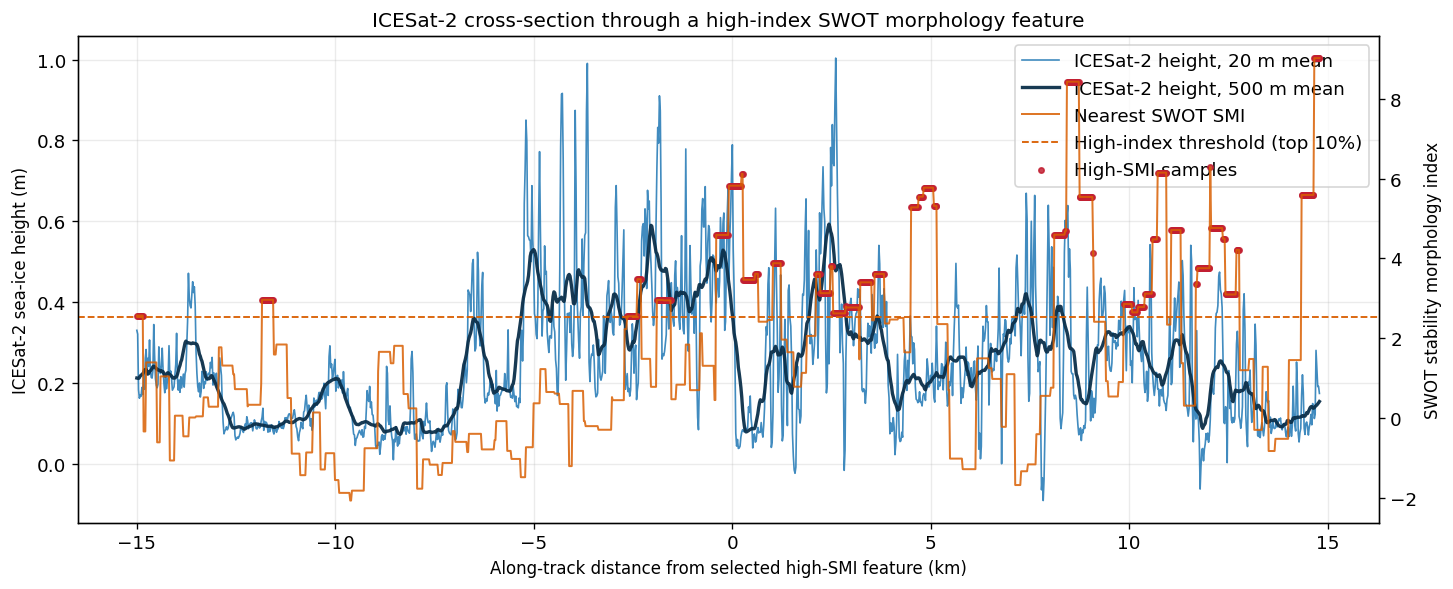

In [10]:
seg = segment.copy()
seg["x_km"] = (seg["distance_m"] - center_distance) / 1000.0
# Thin dense 0.7 m ICESat-2 sampling for plotting while keeping the overall structure.
plot_seg = seg.iloc[::30].copy()

fig, ax1 = plt.subplots(figsize=(12, 4.8), constrained_layout=True)
ax2 = ax1.twinx()

ax1.plot(plot_seg["x_km"], plot_seg["height_20m"], color="#1f77b4", linewidth=1.0, alpha=0.85, label="ICESat-2 height, 20 m mean")
ax1.plot(plot_seg["x_km"], plot_seg["height_500m"], color="#0b2f4a", linewidth=2.0, alpha=0.95, label="ICESat-2 height, 500 m mean")
ax2.plot(plot_seg["x_km"], plot_seg["swot_smi"], color="#d95f02", linewidth=1.2, alpha=0.85, label="Nearest SWOT SMI")
ax2.axhline(high_index_threshold, color="#d95f02", linestyle="--", linewidth=1.1, label=f"High-index threshold ({high_index_label})")

high_plot = plot_seg[plot_seg["swot_smi"] >= high_index_threshold]
ax2.scatter(high_plot["x_km"], high_plot["swot_smi"], s=10, color="#c21f32", alpha=0.85, label="High-SMI samples")

ax1.set_xlabel("Along-track distance from selected high-SMI feature (km)")
ax1.set_ylabel("ICESat-2 sea-ice height (m)")
ax2.set_ylabel("SWOT stability morphology index")
ax1.set_title("ICESat-2 cross-section through a high-index SWOT morphology feature")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True)
ax1.grid(alpha=0.25)

fig_path = FIG_DIR / "icesat2_smi_cross_section_region02_left_gt2l.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

WindowsPath('figures/smi_histogram_region02_left_20230409.png')

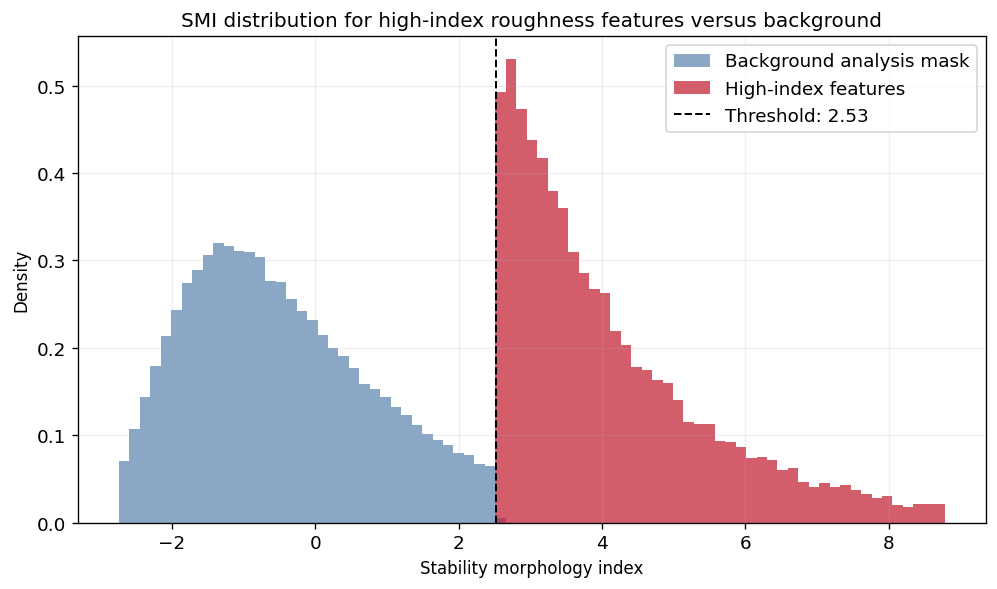

In [11]:
fig, ax = plt.subplots(figsize=(8.2, 4.8), constrained_layout=True)
background_smi = smi[valid & ~high_index_mask]
high_smi = smi[high_index_mask]
bins = np.linspace(np.nanpercentile(smi[valid], 1), np.nanpercentile(smi[valid], 99.5), 80)
ax.hist(background_smi, bins=bins, density=True, alpha=0.65, color="#4c78a8", label="Background analysis mask")
ax.hist(high_smi, bins=bins, density=True, alpha=0.72, color="#c21f32", label="High-index features")
ax.axvline(high_index_threshold, color="black", linestyle="--", linewidth=1.2, label=f"Threshold: {high_index_threshold:.2f}")
ax.set_xlabel("Stability morphology index")
ax.set_ylabel("Density")
ax.set_title("SMI distribution for high-index roughness features versus background")
ax.legend(frameon=True)
ax.grid(alpha=0.2)

fig_path = FIG_DIR / "smi_histogram_region02_left_20230409.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

## 7. Algorithmic Uncertainty Layer

For this prototype, the most immediate validation layer is algorithmic uncertainty. The notebook tests whether the SMI changes dramatically under reasonable choices in:

- window size: 500 m, 1 km, and 2 km;
- threshold: top 5 percent, top 10 percent, and greater than 2 standard deviations above background;
- score components: height-only, backscatter-only, and combined SMI;
- swath/artifact checks: row/column median structure and left/right swath comparison for the same date.

,index_variant,window_m,window_pixels_along,window_pixels_across,threshold,threshold_value,high_index_pixels,high_index_area_km2,feature_count
0,stability_morphology_index,500.0,2,2,top 10%,2.428735,15886,950.655739,579
1,stability_morphology_index,500.0,2,2,top 5%,3.710608,7943,475.327869,369
2,stability_morphology_index,500.0,2,2,>2 SD above background,4.512173,5203,311.359802,271
3,stability_morphology_index,1000.0,4,4,top 10%,2.527558,15886,950.655739,448
4,stability_morphology_index,1000.0,4,4,top 5%,3.782623,7943,475.327869,290
5,stability_morphology_index,1000.0,4,4,>2 SD above background,4.620048,5117,306.213359,218
6,stability_morphology_index,2000.0,8,8,top 10%,2.517259,15884,950.536054,252
7,stability_morphology_index,2000.0,8,8,top 5%,3.769398,7942,475.268027,167
8,stability_morphology_index,2000.0,8,8,>2 SD above background,4.466983,5515,330.030618,141


WindowsPath('figures/smi_window_threshold_sensitivity_region02_left_20230409.png')

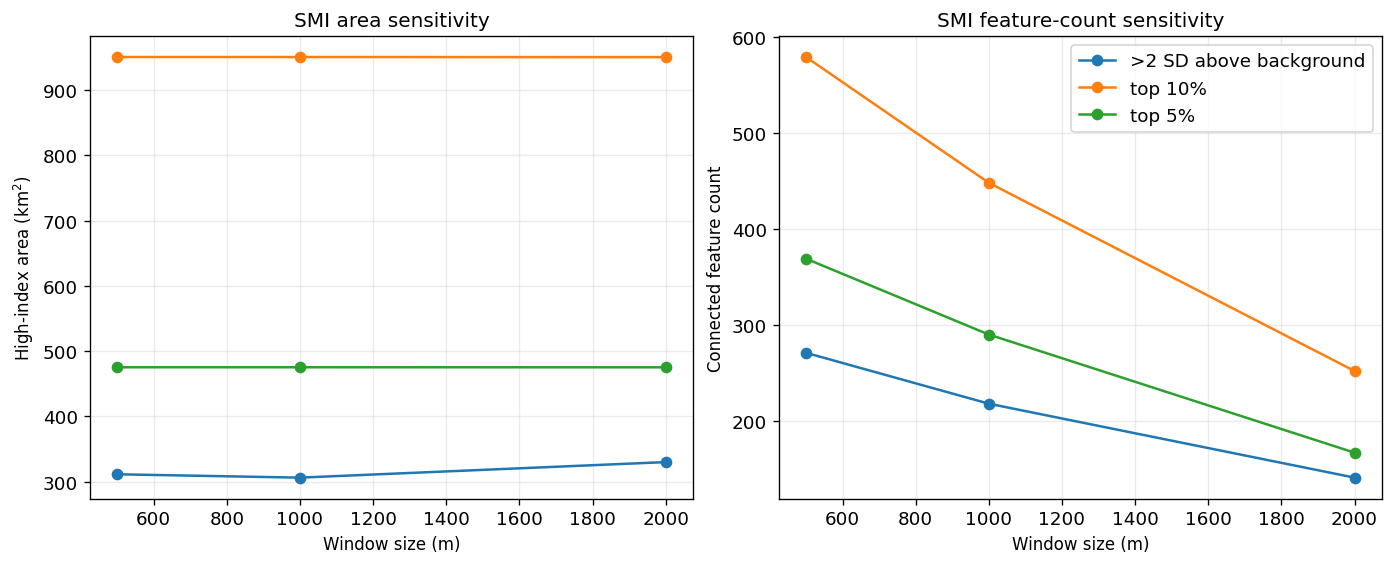

In [12]:
window_threshold_sensitivity = swot_utils.sensitivity_table(
    metrics_by_window,
    thresholds=(0.90, 0.95, "mean+2sd"),
    min_pixels=4,
    index_var="stability_morphology_index",
)
display(window_threshold_sensitivity)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
for label, group in window_threshold_sensitivity.groupby("threshold"):
    group = group.sort_values("window_m")
    axes[0].plot(group["window_m"], group["high_index_area_km2"], marker="o", label=label)
    axes[1].plot(group["window_m"], group["feature_count"], marker="o", label=label)

axes[0].set_xlabel("Window size (m)")
axes[0].set_ylabel("High-index area (km$^2$)")
axes[0].set_title("SMI area sensitivity")
axes[0].grid(alpha=0.25)

axes[1].set_xlabel("Window size (m)")
axes[1].set_ylabel("Connected feature count")
axes[1].set_title("SMI feature-count sensitivity")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=True)

fig_path = FIG_DIR / "smi_window_threshold_sensitivity_region02_left_20230409.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

,index_variant,threshold,threshold_value,high_index_pixels,high_index_area_km2,feature_count
0,height_only_smi,top 10%,1.837553,15886,950.655739,527
1,height_only_smi,top 5%,2.838413,7943,475.327869,306
2,height_only_smi,>2 SD above background,3.756063,4369,261.451273,168
3,backscatter_only_smi,top 10%,1.167827,15886,950.655739,416
4,backscatter_only_smi,top 5%,1.846872,7943,475.327869,226
5,backscatter_only_smi,>2 SD above background,2.000000,6874,411.356386,209
6,stability_morphology_index,top 10%,2.527558,15886,950.655739,448
7,stability_morphology_index,top 5%,3.782623,7943,475.327869,290
8,stability_morphology_index,>2 SD above background,4.620048,5117,306.213359,218


WindowsPath('figures/smi_component_sensitivity_region02_left_20230409.png')

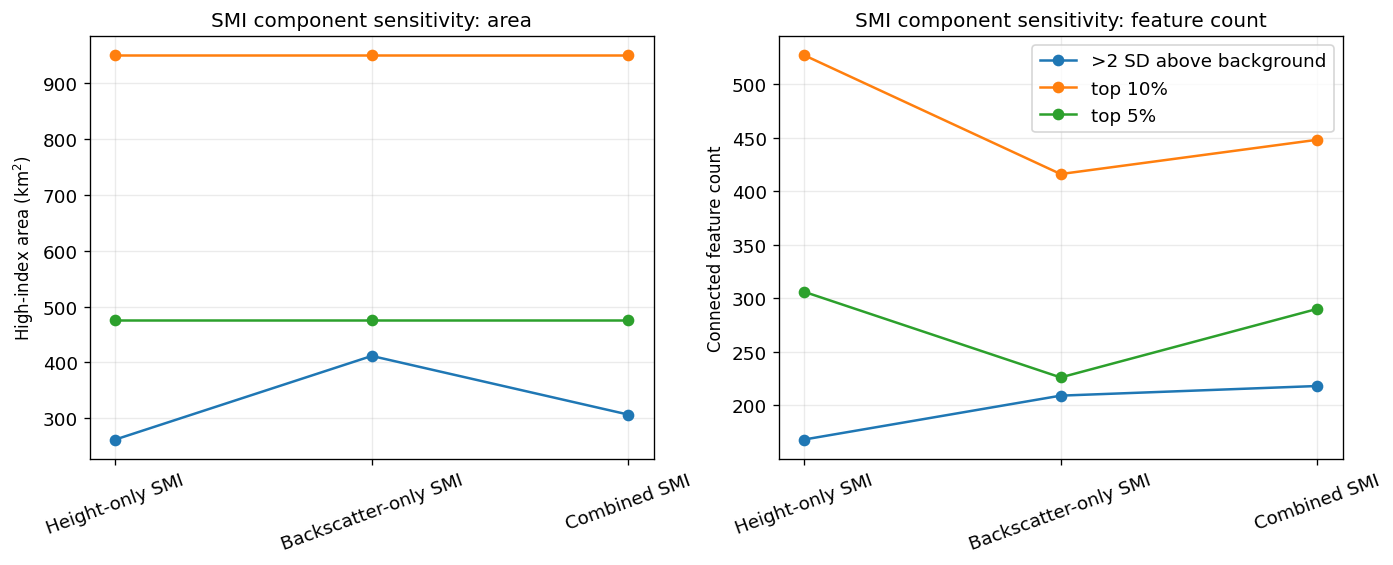

In [13]:
component_sensitivity = swot_utils.component_sensitivity_table(
    metrics,
    index_vars=("height_only_smi", "backscatter_only_smi", "stability_morphology_index"),
    thresholds=(0.90, 0.95, "mean+2sd"),
    min_pixels=4,
)
display(component_sensitivity)

variant_labels = {
    "height_only_smi": "Height-only SMI",
    "backscatter_only_smi": "Backscatter-only SMI",
    "stability_morphology_index": "Combined SMI",
}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), constrained_layout=True)
for threshold, group in component_sensitivity.groupby("threshold"):
    group = group.copy()
    group["label"] = group["index_variant"].map(variant_labels)
    axes[0].plot(group["label"], group["high_index_area_km2"], marker="o", label=threshold)
    axes[1].plot(group["label"], group["feature_count"], marker="o", label=threshold)

for ax in axes:
    ax.tick_params(axis="x", rotation=20)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("High-index area (km$^2$)")
axes[0].set_title("SMI component sensitivity: area")
axes[1].set_ylabel("Connected feature count")
axes[1].set_title("SMI component sensitivity: feature count")
axes[1].legend(frameon=True)

fig_path = FIG_DIR / "smi_component_sensitivity_region02_left_20230409.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

In [14]:
axis_summary_left = swot_utils.swath_axis_artifact_summary(smi, valid)
axis_summary_left["swath"] = "left"

right_swot = swot_utils.open_swot(SWOT_FILE, swath="right")
right_height = right_swot["height"].values.astype(float)
right_sigma0 = right_swot["sigma0"].values.astype(float)
right_mask, _ = swot_utils.provisional_ice_mask(right_height, sigma0=right_sigma0)
right_metrics = swot_utils.compute_morphology(right_swot, window_m=1000, valid_mask=right_mask)
right_smi = right_metrics["stability_morphology_index"].values
axis_summary_right = swot_utils.swath_axis_artifact_summary(right_smi, right_mask)
axis_summary_right["swath"] = "right"

swath_summary = []
for name, metrics_i in [("left", metrics), ("right", right_metrics)]:
    valid_i = metrics_i["valid_mask"].values.astype(bool)
    smi_i = metrics_i["stability_morphology_index"].values
    mask_i, thresh_i, label_i = swot_utils.index_mask(smi_i, valid_mask=valid_i, quantile=0.90)
    spacing_i = {
        "along_m": float(metrics_i.attrs["spacing_along_m"]),
        "across_m": float(metrics_i.attrs["spacing_across_m"]),
    }
    _, features_i = swot_utils.label_index_features(mask_i, spacing=spacing_i, min_pixels=4)
    pixel_area = spacing_i["along_m"] * spacing_i["across_m"] / 1e6
    swath_summary.append({
        "swath": name,
        "valid_pixels": int(valid_i.sum()),
        "smi_p95": float(np.nanpercentile(smi_i[valid_i], 95)),
        "smi_p99": float(np.nanpercentile(smi_i[valid_i], 99)),
        "top10_threshold": thresh_i,
        "top10_area_km2": float(mask_i.sum() * pixel_area),
        "top10_feature_count": int(len(features_i)),
    })

artifact_summary = pd.concat([axis_summary_left, axis_summary_right], ignore_index=True)
swath_summary = pd.DataFrame(swath_summary)
print("Axis-median SMI diagnostics:")
display(artifact_summary)

print("Left/right swath comparison for the same date and window:")
display(swath_summary)

Axis-median SMI diagnostics:


,axis,median_of_axis_medians,std_of_axis_medians,p95_abs_axis_median,swath
0,along-track rows,-0.431109,0.938316,1.909080,left
1,across-track columns,-0.671644,0.908433,1.698034,left
2,along-track rows,-0.487551,0.629753,1.503118,right
3,across-track columns,-0.734180,0.635086,1.148617,right


Left/right swath comparison for the same date and window:


,swath,valid_pixels,smi_p95,smi_p99,top10_threshold,top10_area_km2,top10_feature_count
0,left,159046,3.782623,7.039204,2.527558,950.655739,448
1,right,167634,3.731787,6.483508,2.579733,1001.975260,581


WindowsPath('figures/smi_artifact_checks_region02_20230409.png')

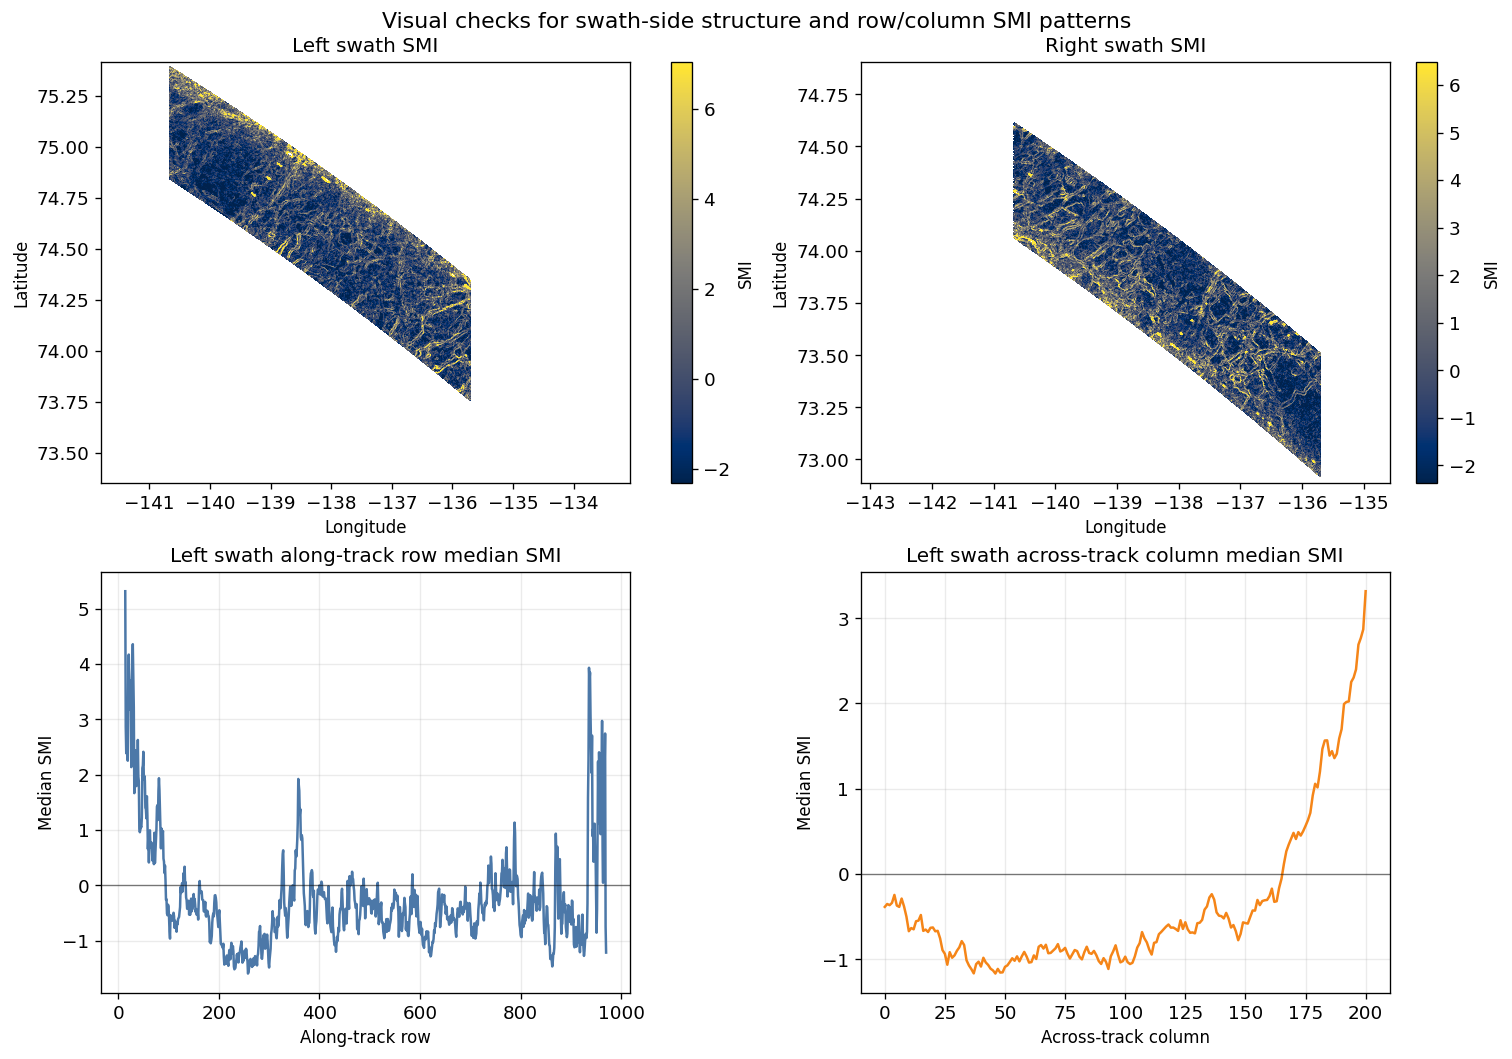

In [15]:
left_row_median = np.nanmedian(np.where(valid, smi, np.nan), axis=1)
left_col_median = np.nanmedian(np.where(valid, smi, np.nan), axis=0)
right_valid = right_metrics["valid_mask"].values.astype(bool)
right_masked_smi = np.where(right_valid, right_smi, np.nan)
right_limits = (np.nanpercentile(right_masked_smi, 5), np.nanpercentile(right_masked_smi, 99))

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5), constrained_layout=True)

im = axes[0, 0].pcolormesh(lon, lat, masked_smi, shading="auto", cmap="cividis", vmin=smi_limits[0], vmax=smi_limits[1])
axes[0, 0].set_title("Left swath SMI")
fig.colorbar(im, ax=axes[0, 0], label="SMI")

im = axes[0, 1].pcolormesh(right_swot["lon"], right_swot["lat"], right_masked_smi, shading="auto", cmap="cividis", vmin=right_limits[0], vmax=right_limits[1])
axes[0, 1].set_title("Right swath SMI")
fig.colorbar(im, ax=axes[0, 1], label="SMI")

axes[1, 0].plot(left_row_median, color="#4c78a8")
axes[1, 0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[1, 0].set_title("Left swath along-track row median SMI")
axes[1, 0].set_xlabel("Along-track row")
axes[1, 0].set_ylabel("Median SMI")
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(left_col_median, color="#f58518")
axes[1, 1].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[1, 1].set_title("Left swath across-track column median SMI")
axes[1, 1].set_xlabel("Across-track column")
axes[1, 1].set_ylabel("Median SMI")
axes[1, 1].grid(alpha=0.25)

for ax in axes[0, :]:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

fig.suptitle("Visual checks for swath-side structure and row/column SMI patterns", y=1.02)
fig_path = FIG_DIR / "smi_artifact_checks_region02_20230409.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path

## 8. Multi-Date SMI Persistence

The dataset includes three Region 02 SWOT scenes:

| Date | File |
|------|------|
| 2023-04-09 | UMD_SWOT_024_BeaufortSea_Study_Region_02_20230409.nc |
| 2023-04-10 | UMD_SWOT_024_BeaufortSea_Study_Region_02_20230410.nc |
| 2023-06-16 | UMD_SWOT_024_BeaufortSea_Study_Region_02_20230616.nc |

If the SMI is tracking real structural features rather than scene-specific noise, high-index areas should be spatially consistent across dates — at minimum for the two consecutive-day scenes (April 9 and 10), and to some degree for June if the same morphological features persist into late spring.

This section:

1. Computes SMI for each date on its native swath grid (1 km window, left swath).
2. Projects all three high-index masks onto a common 0.01° regular grid.
3. Counts how many dates each cell is high-index (0, 1, 2, or 3).
4. Computes pairwise Jaccard similarity between date pairs over their shared spatial coverage.

**Interpretation guide:**
- High Jaccard between April 9 and April 10 (consecutive days) suggests the index is not dominated by single-pass noise.
- Elevated Jaccard between April and June suggests morphological features persist seasonally, consistent with grounded ridges or robust anchoring features.
- Low Jaccard across all pairs suggests the index needs further refinement before persistence analysis is meaningful.


In [16]:
REGION02_FILES = [
    (DATA_DIR / "UMD_SWOT_024_BeaufortSea_Study_Region_02_20230409.nc", "2023-04-09"),
    (DATA_DIR / "UMD_SWOT_024_BeaufortSea_Study_Region_02_20230410.nc", "2023-04-10"),
    (DATA_DIR / "UMD_SWOT_024_BeaufortSea_Study_Region_02_20230616.nc", "2023-06-16"),
]

scenes = []
for path, date_label in REGION02_FILES:
    ds = swot_utils.open_swot(path, swath="left")
    h = ds["height"].values.astype(float)
    s = ds["sigma0"].values.astype(float)
    vmask, _ = swot_utils.provisional_ice_mask(h, sigma0=s)
    met = swot_utils.compute_morphology(ds, window_m=1000, valid_mask=vmask)
    smi_arr = met["stability_morphology_index"].values
    hi_mask, hi_thresh, hi_label = swot_utils.index_mask(smi_arr, valid_mask=vmask, quantile=0.90)
    scenes.append({
        "date": date_label,
        "lon": ds["lon"].values,
        "lat": ds["lat"].values,
        "smi": smi_arr,
        "valid": vmask,
        "hi_mask": hi_mask,
        "hi_thresh": hi_thresh,
    })
    print(f"{date_label}: {vmask.sum():,} valid pixels, {hi_mask.sum():,} high-index ({hi_label})")

# Project all scenes onto a common 0.01 degree regular grid.
lon_centers, lat_centers = swot_utils.make_common_grid(
    [sc["lon"] for sc in scenes],
    [sc["lat"] for sc in scenes],
    [sc["valid"] for sc in scenes],
    resolution_deg=0.01,
)

for sc in scenes:
    smi_grid, hi_grid = swot_utils.rasterize_smi(
        sc["lon"], sc["lat"], sc["smi"], sc["hi_mask"], sc["valid"],
        lon_centers, lat_centers,
    )
    sc["smi_grid"] = smi_grid
    sc["hi_grid"] = hi_grid

count_grid, coverage_grid = swot_utils.persistence_count(
    [sc["hi_grid"] for sc in scenes], hi_threshold=0.5
)

# Pairwise Jaccard similarity.
dates = [sc["date"] for sc in scenes]
jaccard_rows = []
for i in range(len(scenes)):
    for j in range(i + 1, len(scenes)):
        j_val = swot_utils.jaccard_similarity(scenes[i]["hi_grid"], scenes[j]["hi_grid"])
        shared = int((np.isfinite(scenes[i]["hi_grid"]) & np.isfinite(scenes[j]["hi_grid"])).sum())
        jaccard_rows.append({
            "date_a": dates[i], "date_b": dates[j],
            "jaccard": round(float(j_val), 3) if np.isfinite(j_val) else np.nan,
            "shared_cells": shared,
        })
jaccard_table = pd.DataFrame(jaccard_rows)
print("\nPairwise Jaccard similarity (high-index mask, top 10%, 1 km window):")
display(jaccard_table)

for n in range(1, len(scenes) + 1):
    cells = int(np.sum(count_grid == n))
    print(f"Cells high-index on exactly {n} of {len(scenes)} dates: {cells:,}")


2023-04-09: 159,046 valid pixels, 15,886 high-index (top 10%)


2023-04-10: 159,111 valid pixels, 15,893 high-index (top 10%)


2023-06-16: 158,898 valid pixels, 15,871 high-index (top 10%)



Pairwise Jaccard similarity (high-index mask, top 10%, 1 km window):


,date_a,date_b,jaccard,shared_cells
0,2023-04-09,2023-04-10,0.166,29253
1,2023-04-09,2023-06-16,0.071,28981
2,2023-04-10,2023-06-16,0.076,28963


Cells high-index on exactly 1 of 3 dates: 5,618
Cells high-index on exactly 2 of 3 dates: 1,213
Cells high-index on exactly 3 of 3 dates: 115


C:\Users\as1612\AppData\Local\Temp\ipykernel_46672\3252657977.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_persist = plt.cm.get_cmap("YlOrRd", 4)


WindowsPath('figures/smi_persistence_region02_left.png')

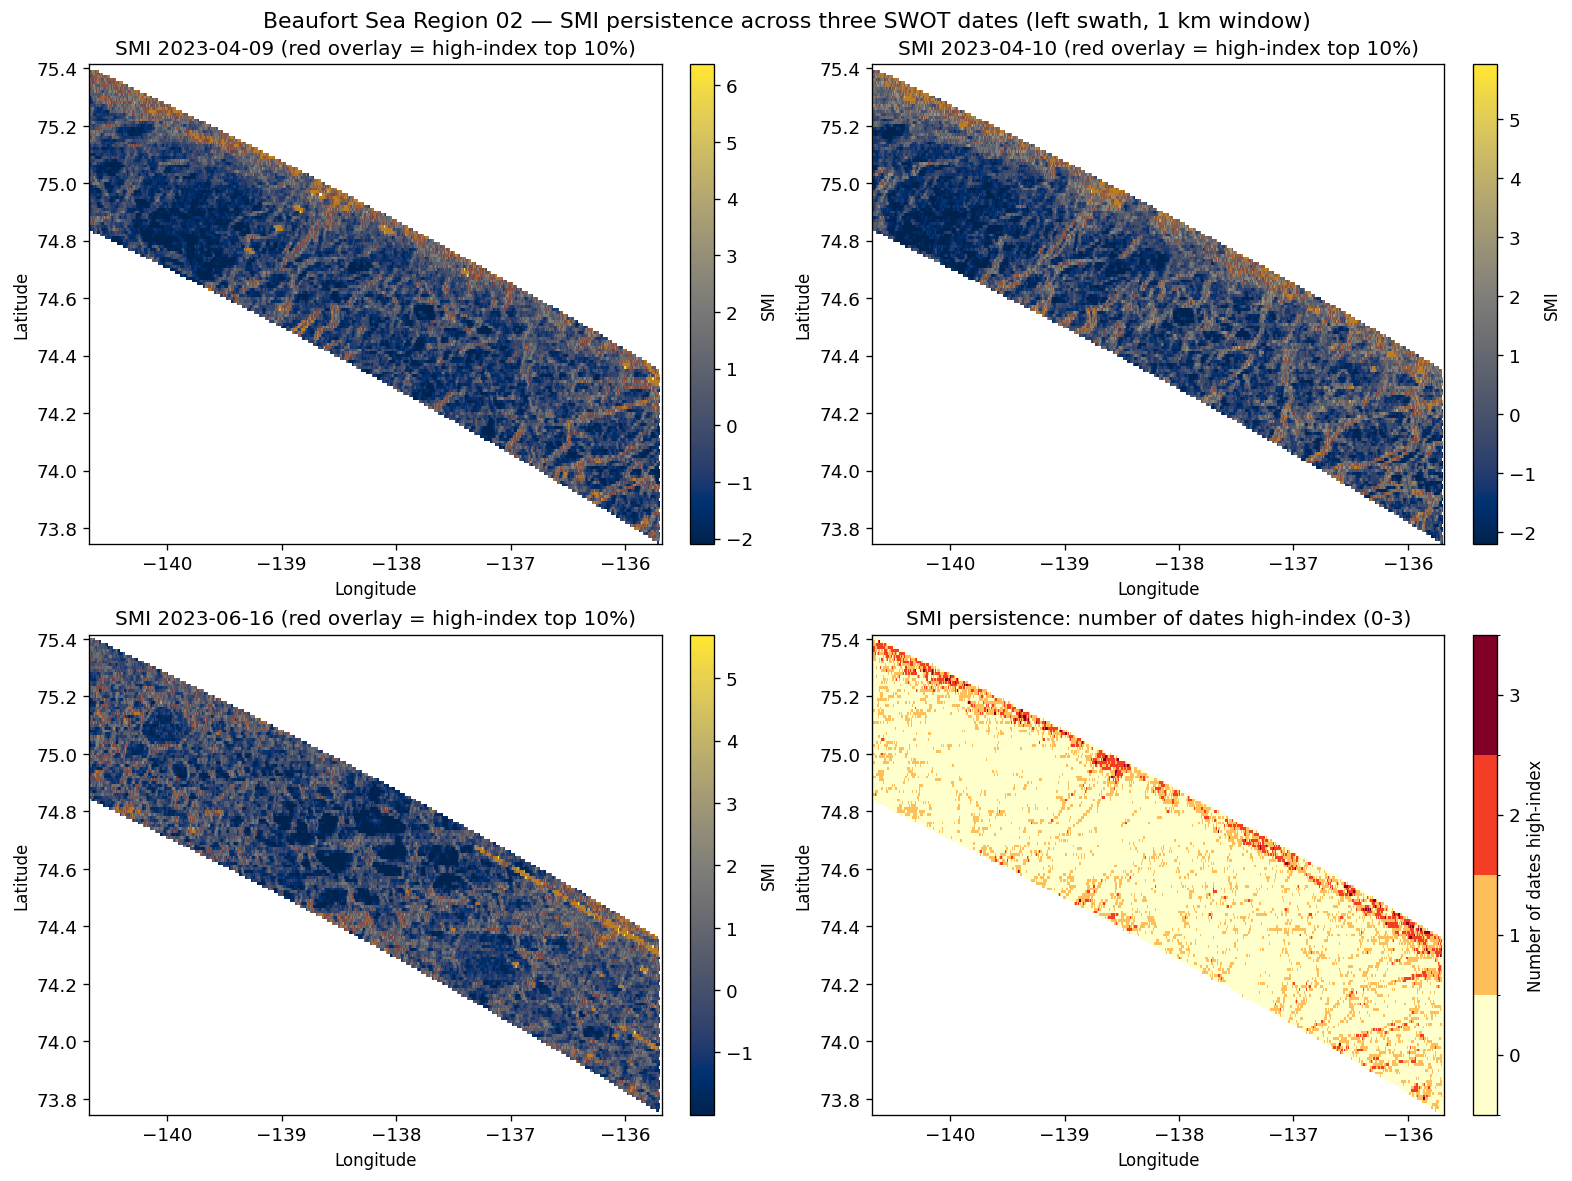

In [17]:
from matplotlib.colors import BoundaryNorm

fig, axes = plt.subplots(2, 2, figsize=(13, 9.5), constrained_layout=True)
lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)

for ax, sc in zip(axes.flat[:3], scenes):
    masked_smi = np.where(np.isfinite(sc["smi_grid"]), sc["smi_grid"], np.nan)
    vmin, vmax = np.nanpercentile(masked_smi, 5), np.nanpercentile(masked_smi, 99)
    im = ax.pcolormesh(lon_grid_2d, lat_grid_2d, masked_smi,
                       shading="auto", cmap="cividis", vmin=vmin, vmax=vmax)
    hi_overlay = np.where(sc["hi_grid"] >= 0.5, 1.0, np.nan)
    ax.pcolormesh(lon_grid_2d, lat_grid_2d, hi_overlay,
                  shading="auto", cmap="Reds", alpha=0.45, vmin=0, vmax=1)
    ax.set_title(f"SMI {sc['date']} (red overlay = high-index top 10%)")
    fig.colorbar(im, ax=ax, label="SMI")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

ax4 = axes.flat[3]
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
cmap_persist = plt.cm.get_cmap("YlOrRd", 4)
norm_persist = BoundaryNorm(bounds, cmap_persist.N)
im4 = ax4.pcolormesh(lon_grid_2d, lat_grid_2d,
                     np.where(np.isfinite(count_grid), count_grid, np.nan),
                     shading="auto", cmap=cmap_persist, norm=norm_persist)
fig.colorbar(im4, ax=ax4, ticks=[0, 1, 2, 3], label="Number of dates high-index")
ax4.set_title("SMI persistence: number of dates high-index (0-3)")
ax4.set_xlabel("Longitude")
ax4.set_ylabel("Latitude")

fig.suptitle(
    "Beaufort Sea Region 02 — SMI persistence across three SWOT dates (left swath, 1 km window)",
    y=1.02,
)
fig_path = FIG_DIR / "smi_persistence_region02_left.png"
fig.savefig(fig_path, bbox_inches="tight")
fig_path


## Future Validation Layers

1. **Breakout prediction layer**
   Compare SWOT roughness/ridge/anchor metrics before breakup against observed breakup locations or dates.

2. **SAR persistence layer**
   Use Sentinel-1 to classify landfast versus mobile ice before and after the SWOT scene, then test whether SWOT morphology predicts which zones remain attached.

3. **Bathymetric grounding layer**
   Combine SWOT roughness features with bathymetry to identify candidate grounded ridges or shallow-water anchoring zones, then test whether high-roughness features occur at plausible grounding depths.

4. **Model-parameterization layer**
   Convert SWOT-derived roughness, ridge density, or morphology-index statistics into parameters relevant to coastal drag, internal ice strength, or landfast-ice anchoring in models.

5. **Algorithmic uncertainty layer**
   Quantify how stable the morphology index is under swath-side differences, window size, threshold choice, score-component choice, and known SWOT sea-ice artifacts.

The current notebook prioritizes the fifth layer because it is doable immediately with the existing dataset.

## Interpretation Notes

In this case scene, the SWOT fields show coherent 2D height and backscatter structures that survive a simple local-morphology index workflow. The high-index mask highlights a connected network of roughness, gradient, and backscatter-texture anomalies. Along the spatially overlapping ICESat-2 beam, top sampled SMI values have somewhat higher local ICESat-2 height variability than background sampled values, which is consistent with enhanced surface morphology but does not prove grounding, anchoring, thickness, or stability.

The method is useful if it produces coherent, robust, interpretable morphology features that can be carried forward into future validation against breakout or persistence data. High-index areas are candidate morphology features only. They are not confirmed grounded ridges, anchor points, thickness anomalies, or stable landfast-ice zones.